In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df=pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data preprocessing

## Handle missing data

In [5]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [7]:
# Age
df["Age"]=2026-df["Year_Birth"]

In [8]:
#Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
ref_date=df["Dt_Customer"].max()
df["Customer_tenure_days"]=(ref_date-df["Dt_Customer"]).dt.days

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days'],
      dtype='object')

In [10]:
#Total Spending
df["total_spend"]=df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
# Total children 
df["Total_Children"]=df["Kidhome"] + df["Teenhome"]

In [12]:
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "PhD":"Postgraduate","Master":"Postgraduate",
    "Graduation":"Graduate"
})
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [13]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days', 'total_spend',
       'Total_Children', 'Living_with'],
      dtype='object')

In [16]:
cols=["ID","Year_Birth","Kidhome","Marital_Status","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntGoldProds","MntFishProducts","MntSweetProducts"]
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)

In [17]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_spend,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [18]:
df.shape

(2240, 27)

## Handling Outliers

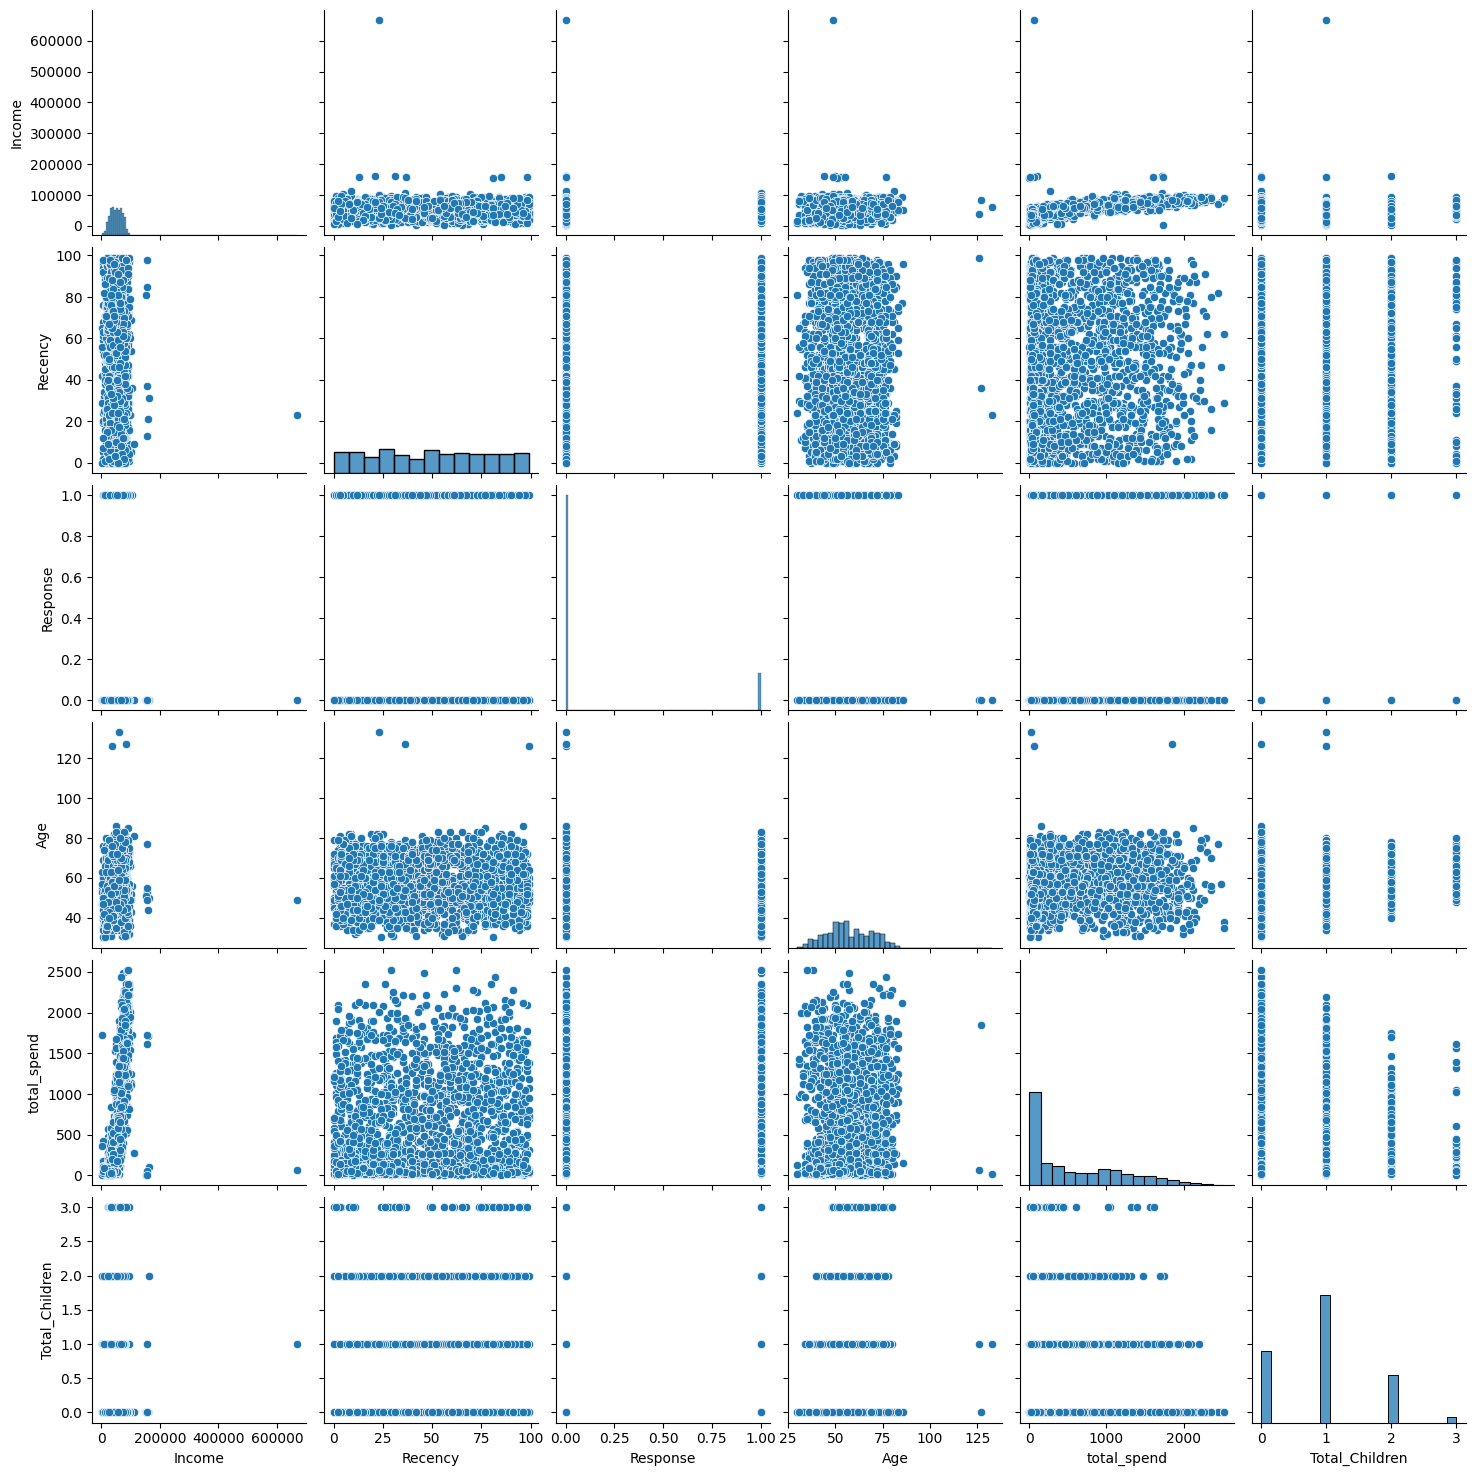

In [19]:

cols=["Income","Recency","Response","Age","total_spend","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [20]:
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]
print(len(df_cleaned))

2236


# Heatmap

In [21]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

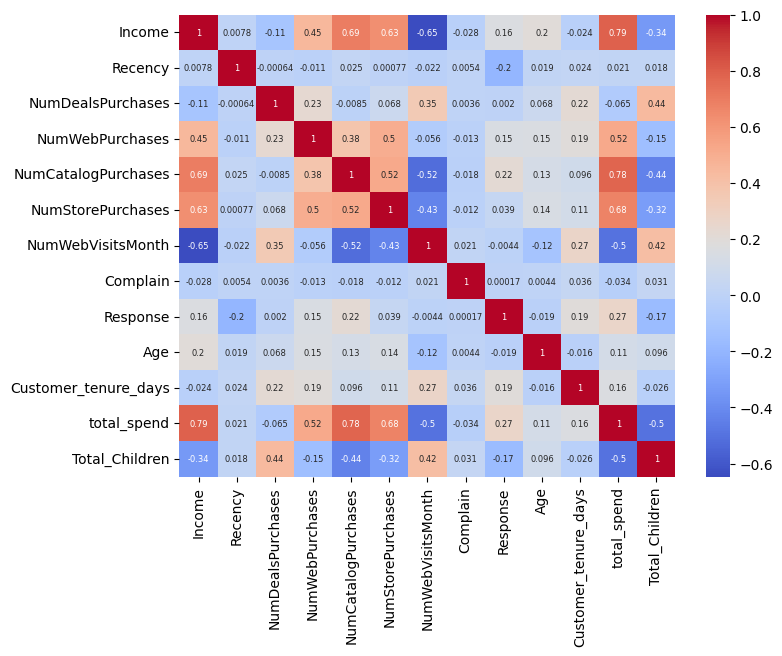

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

## Encoding 

In [23]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [25]:
df_enc=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [26]:
df_enc.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_spend,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [27]:
X=df_enc

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## Visualizing

In [30]:
from sklearn.decomposition import PCA

In [31]:
# 2D 
pca=PCA(
    n_components=3
)
X_pca=pca.fit_transform(X_scaled)

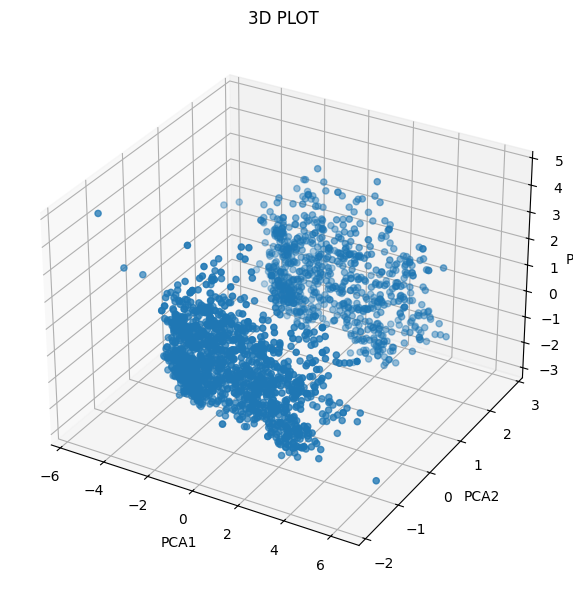

In [32]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D PLOT")
plt.tight_layout()

# Choosing K value
## 1. Elbow Method

In [33]:
from sklearn.cluster import KMeans
from kneed import KneeLocator 
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [34]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
opt_k=knee.elbow
print("Optimal K:",opt_k)

Optimal K: 4


[18093.257793324527, 10760.843401758224, 8830.288717243035, 6650.969417658867, 5006.161168001193, 4396.308699108107, 3857.6330644275718, 3207.0576242216625, 3025.2232554325847, 2651.442989106148]


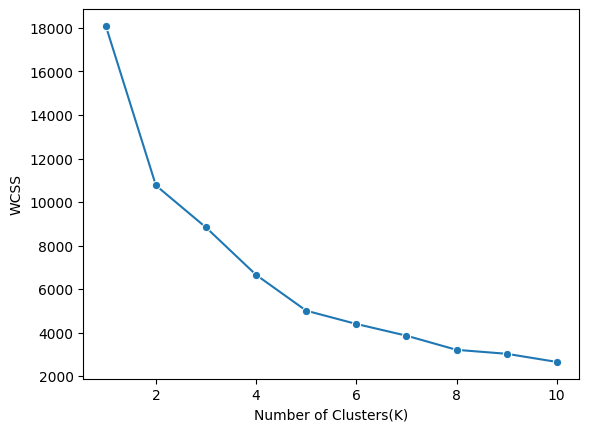

In [35]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
print(wcss)

## 2. Silhouette Score

[0.3715793907976336, 0.307688192747433, 0.3580996159596429, 0.4000152147661341, 0.39929183898567977, 0.40262087405588853, 0.4050858828690929, 0.40118897046529645, 0.40291173364821137]


Text(0, 0.5, 'WCSS')

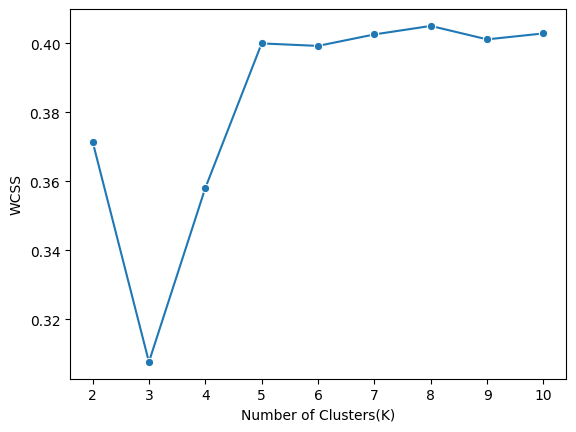

In [36]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,label)
    scores.append(score)
print(scores)
#plot
sns.lineplot(x=range(2,11),y=scores,marker="o")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")

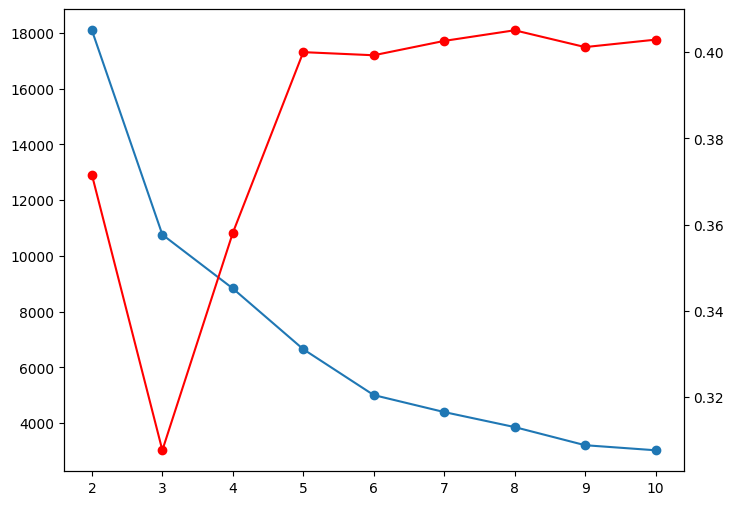

In [37]:
# Combined Plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6)) 
ax1.plot(k_range,wcss[:len(k_range)],marker="o")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="o",color="red")

In [38]:
# KMeans Clustering 
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

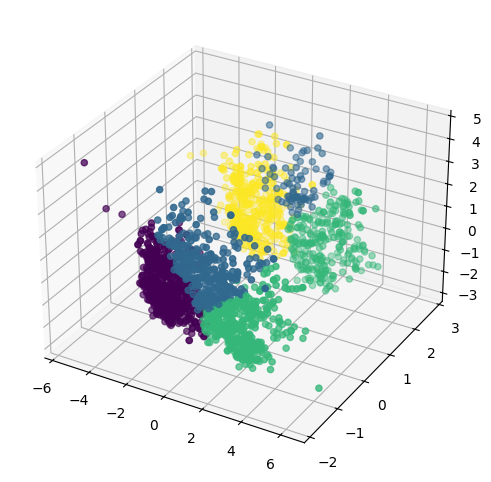

In [39]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [42]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

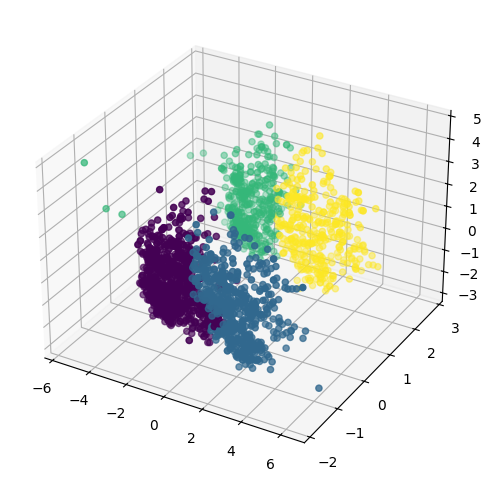

In [43]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [56]:
# Characterization of Clusters
X["clusters"]=labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_spend,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

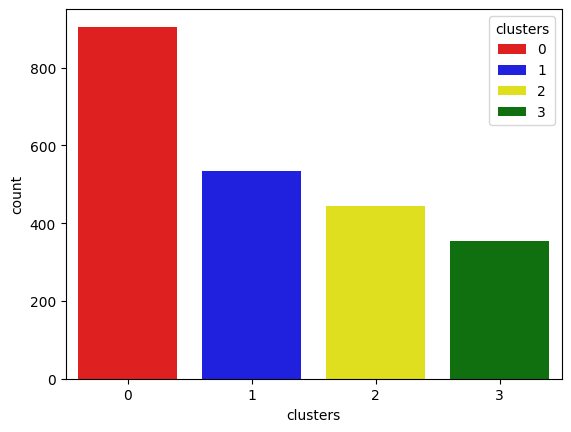

In [57]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='total_spend', ylabel='Income'>

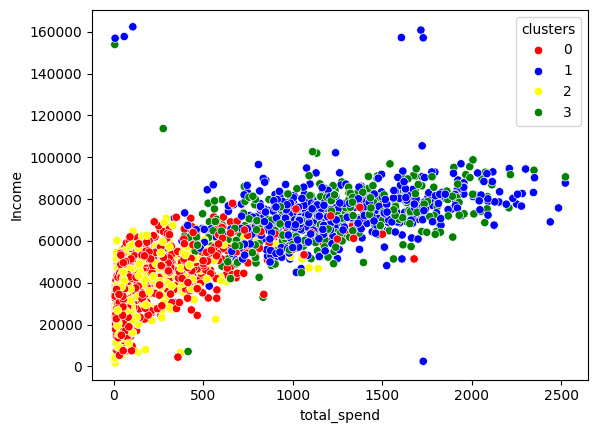

In [58]:
sns.scatterplot(x=X["total_spend"],y=X["Income"],hue=X["clusters"],palette=pal)

In [59]:
cluster_summary=X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure_days  total_spend  \
cluste